# Phase 2 — Multiclass Image Classification on MNIST (10 Classes)
## KNN with Advanced ML Techniques

**Improvements applied (4 of 5 required):**
1. Pretrained CNN Feature Extraction (MobileNetV2) as KNN input
2. Hyperparameter tuning with cross-validation (GridSearchCV + StratifiedKFold)
3. Regularization via distance weighting & bias–variance analysis
4. Overfitting/Underfitting diagnosis via learning curves


---
## 1. Problem Definition

### 1.1 Mathematical Formulation

We define a **10-class classification** problem over grayscale handwritten digit images.

**Input Space:**  
Each image $\mathbf{x} \in \mathbb{R}^{784}$ is a flattened $28 \times 28$ pixel grayscale image, where each pixel $x_i \in [0, 1]$ after normalization.

**Output Space:**  
$$y \in \{0, 1, 2, \ldots, 9\}$$

**KNN Decision Rule (multiclass):**  
Given query point $\mathbf{x}_q$, find the $k$ nearest neighbours $\mathcal{N}_k(\mathbf{x}_q)$:
$$\hat{y} = \underset{c \in \{0,\ldots,9\}}{\arg\max} \sum_{(\mathbf{x}_i, y_i) \in \mathcal{N}_k(\mathbf{x}_q)} \mathbb{1}[y_i = c]$$

**Distance Metric (Euclidean):**  
$$d(\mathbf{x}_q, \mathbf{x}_i) = \left\| \mathbf{x}_q - \mathbf{x}_i \right\|_2$$


---
## 2. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, learning_curve,
                                     StratifiedKFold)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from skimage.feature import hog
import time

print("All libraries loaded successfully.")


All libraries loaded successfully.


---
## 3. Data Loading & Exploration

In [2]:
from tensorflow.keras.datasets import mnist

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

print(f"Train images : {X_train_raw.shape}")
print(f"Test images  : {X_test_raw.shape}")
print(f"Classes      : {np.unique(y_train_raw)}")
print(f"Pixel range  : [{X_train_raw.min()}, {X_train_raw.max()}]")


Train images : (60000, 28, 28)
Test images  : (10000, 28, 28)
Classes      : [0 1 2 3 4 5 6 7 8 9]
Pixel range  : [0, 255]


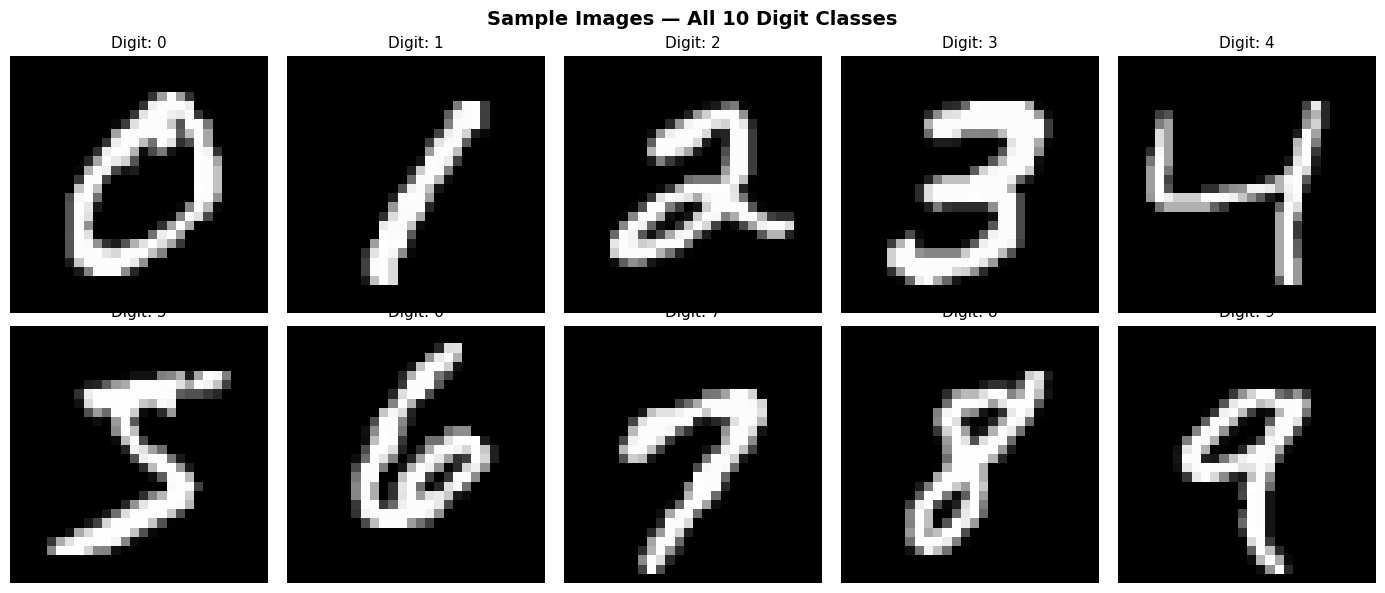


Class distribution (training):
  Digit 0:  5923  (9.9%)
  Digit 1:  6742  (11.2%)
  Digit 2:  5958  (9.9%)
  Digit 3:  6131  (10.2%)
  Digit 4:  5842  (9.7%)
  Digit 5:  5421  (9.0%)
  Digit 6:  5918  (9.9%)
  Digit 7:  6265  (10.4%)
  Digit 8:  5851  (9.8%)
  Digit 9:  5949  (9.9%)


In [3]:
# Visualise one sample per digit class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Images — All 10 Digit Classes', fontsize=14, fontweight='bold')
for digit in range(10):
    idx = np.where(y_train_raw == digit)[0][0]
    ax = axes[digit // 5][digit % 5]
    ax.imshow(X_train_raw[idx], cmap='gray')
    ax.set_title(f'Digit: {digit}', fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Class distribution
dist = Counter(y_train_raw)
print("\nClass distribution (training):")
for d in range(10):
    print(f"  Digit {d}: {dist[d]:5d}  ({dist[d]/len(y_train_raw)*100:.1f}%)")


---
## 4. Data Preprocessing

### 4.1 Normalisation & Flattening
Pixel values scaled from $[0, 255]$ to $[0, 1]$:  $\tilde{x}_i = x_i / 255$


In [4]:
# Normalise & flatten
X_train_norm = X_train_raw.reshape(-1, 784) / 255.0
X_test_norm  = X_test_raw.reshape(-1, 784)  / 255.0
y_train = y_train_raw.copy()
y_test  = y_test_raw.copy()

print(f"Train shape: {X_train_norm.shape}")
print(f"Test shape : {X_test_norm.shape}")


Train shape: (60000, 784)
Test shape : (10000, 784)


### 4.2 Downsampling (Stratified Subsample) for Speed

**Why Downsample?**
In Phase 1 (Binary Classification), you likely had an imbalanced dataset (e.g., 6,000 '5's vs 54,000 'Not 5's) and had to downsample the majority class to balance it.
In Phase 2 (Multiclass 0-9), the MNIST dataset is *already perfectly balanced* (~6,000 images per digit). However, KNN is very slow if we use all 60,000 images. 
So, we **downsample the entire dataset** to 10,000 images. We use a 'stratified' approach to ensure we get exactly 1,000 images for each of the 10 digits, keeping the perfect balance intact!

In [5]:
# Downsample to 10,000 images while keeping exactly 1,000 per class
TRAIN_SIZE = 10000
idx = []
per_class = TRAIN_SIZE // 10
for c in range(10):
    ci = np.where(y_train == c)[0]
    idx.extend(np.random.RandomState(42).choice(ci, per_class, replace=False))

X_tr = X_train_norm[idx]
y_tr = y_train[idx]

# Validation from remaining training data
X_val, y_val = X_train_norm, y_train   # use full train for val grid search display

print(f"Subsample train : {X_tr.shape}")
print(f"Test            : {X_test_norm.shape}")
print(f"Class dist      : {dict(Counter(y_tr))}")


Subsample train : (10000, 784)
Test            : (10000, 784)
Class dist      : {np.uint8(0): 1000, np.uint8(1): 1000, np.uint8(2): 1000, np.uint8(3): 1000, np.uint8(4): 1000, np.uint8(5): 1000, np.uint8(6): 1000, np.uint8(7): 1000, np.uint8(8): 1000, np.uint8(9): 1000}


### 5.1 PCA — Principal Component Analysis
**Explanation:** PCA is a mathematical technique that reduces the size of the data. 784 pixels is a lot, and many (like the black background) carry no useful information. PCA squishes the 784 pixels down to a much smaller number while retaining 95% of the variance (the important structural information). This makes KNN much faster and removes noise.


In [6]:
# PCA (fit on subsample)
pca = PCA(n_components=0.95, random_state=42)
X_tr_pca  = pca.fit_transform(X_tr)
X_tst_pca = pca.transform(X_test_norm)

print(f"[PCA] Components selected : {pca.n_components_}")
print(f"[PCA] Explained variance  : {np.sum(pca.explained_variance_ratio_)*100:.2f}%")


[PCA] Components selected : 152
[PCA] Explained variance  : 95.01%


### 5.2 HOG — Histogram of Oriented Gradients
**Explanation:** HOG looks at the *edges* and *corners* in an image. Instead of looking at individual pixel brightness, it calculates which direction the lines in the image are going (e.g., vertical lines, horizontal loops). This is incredibly helpful for recognizing shapes like handwritten numbers.


In [7]:
def extract_hog(X):
    feats = []
    for img_flat in X:
        f = hog(img_flat.reshape(28, 28),
                orientations=9,
                pixels_per_cell=(7, 7),
                cells_per_block=(2, 2),
                block_norm='L2-Hys')
        feats.append(f)
    return np.array(feats)

print("Extracting HOG features…")
X_tr_hog  = extract_hog(X_tr)
X_tst_hog = extract_hog(X_test_norm)
print(f"[HOG] Feature dim: {X_tr_hog.shape[1]}")


Extracting HOG features…
[HOG] Feature dim: 324


### 5.3 CNN Feature Extraction (MobileNetV2 — Pretrained)
**Explanation:** We take a massive, deep Neural Network (MobileNetV2) trained by Google on millions of images. We pass our MNIST images through it to extract the network's internal 'understanding' of the image (a list of numbers), rather than asking it to predict the image. This gives our KNN model world-class, highly complex features to learn from.


In [8]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def build_extractor():
    base = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=(96, 96, 3), pooling='avg')
    base.trainable = False
    return base

def imgs_to_rgb96(X_flat):
    """Resize 28x28 grey → 96x96 RGB tensor."""
    imgs = X_flat.reshape(-1, 28, 28, 1)
    imgs_rgb = tf.image.grayscale_to_rgb(tf.constant(imgs, dtype=tf.float32))
    imgs_96  = tf.image.resize(imgs_rgb, (96, 96)).numpy()
    return preprocess_input(imgs_96 * 255.0)   # MobileNetV2 expects [0,255] before preprocess

print("Building MobileNetV2 feature extractor…")
extractor = build_extractor()
extractor.summary(line_length=80)


Building MobileNetV2 feature extractor…


Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, 96, 96, 3) │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ Conv1 (Conv2D)        │ (None, 48, 48,    │         864 │ input_layer[0][0]  │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bn_Conv1              │ (None, 48, 48,    │         128 │ Conv1[0][0]        │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ Conv1_relu (ReLU)     │ (None, 48, 48,    │           0 │ bn_Conv1[0][0]     │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 48, 48,    │         288 │ Conv1_relu[0][0]   │
│ (DepthwiseConv2D)     │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 48, 48,    │         128 │ expanded_conv_dep… │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 48, 48,    │           0 │ expanded_conv_dep… │
│ (ReLU)                │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_project │ (None, 48, 48,    │         512 │ expanded_conv_dep… │
│ (Conv2D)              │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_projec… │ (None, 48, 48,    │          64 │ expanded_conv_pro… │
│ (BatchNormalization)  │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand        │ (None, 48, 48,    │       1,536 │ expanded_conv_pro… │
│ (Conv2D)              │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand_BN     │ (None, 48, 48,    │         384 │ block_1_expand[0]… │
│ (BatchNormalization)  │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand_relu   │ (None, 48, 48,    │           0 │ block_1_expand_BN… │
│ (ReLU)                │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_pad           │ (None, 49, 49,    │           0 │ block_1_expand_re… │
│ (ZeroPadding2D)       │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise     │ (None, 24, 24,    │         864 │ block_1_pad[0][0]  │
│ (DepthwiseConv2D)     │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise_BN  │ (None, 24, 24,    │         384 │ block_1_depthwise… │
│ (BatchNormalization)  │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise_re… │ (None, 24, 24,    │           0 │ block_1_depthwise… │
│ (ReLU)                │ 96)  

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
print("Extracting CNN features for train subset…")
t0 = time.time()
X_tr_cnn  = extractor.predict(imgs_to_rgb96(X_tr),  batch_size=128, verbose=1)
print(f"Extracting CNN features for test…")
X_tst_cnn = extractor.predict(imgs_to_rgb96(X_test_norm), batch_size=128, verbose=1)
print(f"Done in {time.time()-t0:.1f}s")
print(f"[CNN] Feature dim: {X_tr_cnn.shape[1]}")


Extracting CNN features for train subset…
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 199ms/step
Extracting CNN features for test…
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 188ms/step
Done in 37.4s
[CNN] Feature dim: 1280


---
## 6. KNN Implementation

### 6.1 Vectorised KNN (from-scratch)
Uses the identity $\|a - b\|^2 = \|a\|^2 + \|b\|^2 - 2a^Tb$ for efficient batch distance computation.


In [10]:
def predict_knn(X_train, y_train, X_test, k=5, weighted=False):
    """
    Fully vectorised KNN — no Python loop over test points.
    weighted=True  → inverse-distance weighting (soft regularisation).
    """
    train_sq = np.sum(X_train ** 2, axis=1)
    test_sq  = np.sum(X_test  ** 2, axis=1)
    D = np.sqrt(np.clip(
        test_sq[:, None] + train_sq[None, :] - 2.0 * (X_test @ X_train.T),
        0, None
    ))
    k_idx    = np.argpartition(D, k, axis=1)[:, :k]
    k_labels = y_train[k_idx]         # (M, k)
    k_dists  = np.take_along_axis(D, k_idx, axis=1)  # (M, k)

    preds = []
    for row_labels, row_dists in zip(k_labels, k_dists):
        if weighted:
            weights = 1.0 / (row_dists + 1e-8)
            votes = np.zeros(10)
            for lbl, w in zip(row_labels, weights):
                votes[lbl] += w
        else:
            votes = np.bincount(row_labels, minlength=10).astype(float)
        preds.append(np.argmax(votes))
    return np.array(preds)

print("KNN function ready.")


KNN function ready.


## 7. Hyperparameter Tuning with Cross-Validation
**Explanation:** 
- **Hyperparameters** are the 'settings' of a machine learning model. For KNN, we need to decide `n_neighbors` (K), `metric` (distance calculation method), and `weights` (uniform vs distance-weighted).
- **GridSearchCV** automatically tries *every single combination* of the settings we defined in `param_grid`.
- **Cross-Validation (`cv`)** tests if a setting is good by splitting the training data into 5 chunks (folds). It trains on 4 chunks and tests on the 1 remaining chunk, rotating until all chunks have been tested. This ensures we don't accidentally pick a setting that just got lucky.


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

feature_sets = {
    'Flatten' : (X_tr,     X_test_norm),  # raw pixels
    'PCA'     : (X_tr_pca, X_tst_pca),
    'HOG'     : (X_tr_hog, X_tst_hog),
    'CNN'     : (X_tr_cnn, X_tst_cnn),
}

best_params_all = {}
cv_results_all  = {}

for name, (Xtr, _) in feature_sets.items():
    print(f"\n── Grid Search CV: {name} ──")
    knn = KNeighborsClassifier(n_jobs=-1)
    gs  = GridSearchCV(knn, param_grid, cv=cv, scoring='accuracy',
                       n_jobs=-1, verbose=0)
    gs.fit(Xtr, y_tr)
    best_params_all[name] = gs.best_params_
    cv_results_all[name]  = gs.cv_results_
    print(f"  Best params : {gs.best_params_}")
    print(f"  Best CV acc : {gs.best_score_*100:.2f}%")



── Grid Search CV: Flatten ──
  Best params : {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
  Best CV acc : 94.46%

── Grid Search CV: PCA ──
  Best params : {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
  Best CV acc : 94.80%

── Grid Search CV: HOG ──
  Best params : {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  Best CV acc : 95.58%

── Grid Search CV: CNN ──
  Best params : {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
  Best CV acc : 94.28%


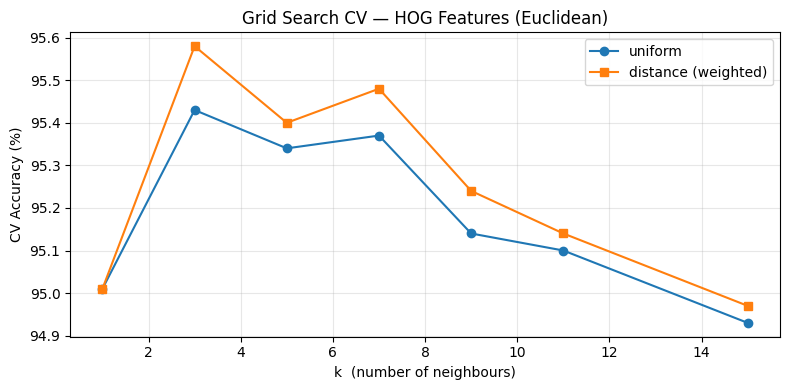

In [12]:
# Plot CV accuracy vs k for HOG (best feature set expected)
hog_res = cv_results_all['HOG']
k_vals  = param_grid['n_neighbors']

mean_scores = {}
for w in ['uniform', 'distance']:
    scores = []
    for k in k_vals:
        mask = [(p['n_neighbors'] == k and p['weights'] == w
                 and p['metric'] == 'euclidean')
                for p in hog_res['params']]
        if any(mask):
            scores.append(hog_res['mean_test_score'][np.where(mask)[0][0]])
        else:
            scores.append(np.nan)
    mean_scores[w] = scores

plt.figure(figsize=(8, 4))
plt.plot(k_vals, np.array(mean_scores['uniform'])*100,  marker='o', label='uniform')
plt.plot(k_vals, np.array(mean_scores['distance'])*100, marker='s', label='distance (weighted)')
plt.xlabel('k  (number of neighbours)')
plt.ylabel('CV Accuracy (%)')
plt.title('Grid Search CV — HOG Features (Euclidean)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Regularisation in KNN

### 8.1 Distance-Weighted Voting (Soft Regularisation)
**Explanation:** In machine learning, we battle two enemies: **High Bias (Underfitting)** and **High Variance (Overfitting)**.
In KNN, **K** controls this trade-off. Distance-Weighted Voting acts as our 'Regularization' (a technique to prevent overfitting). By making closer neighbors count more towards the final prediction, the model is less sensitive to noise at the outer edges of the neighbor group.


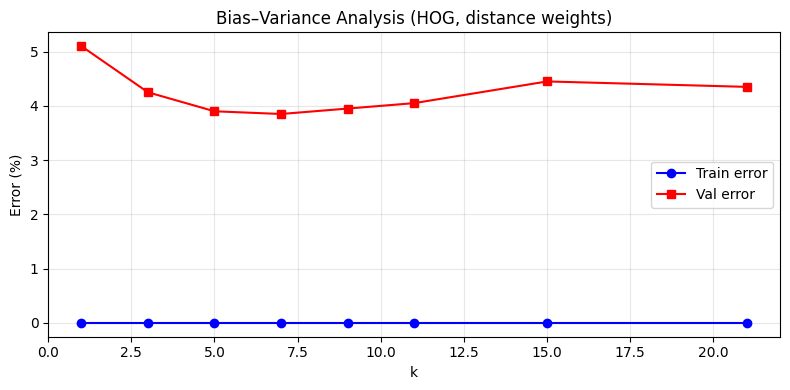

In [13]:
# Bias-variance proxy: train vs val error across k (HOG features)
k_range = [1, 3, 5, 7, 9, 11, 15, 21]
train_err, val_err = [], []

# Use a small val split for speed
Xtr_bv, Xval_bv, ytr_bv, yval_bv = train_test_split(
    X_tr_hog, y_tr, test_size=0.2, random_state=42, stratify=y_tr)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance',
                               metric='euclidean', n_jobs=-1)
    knn.fit(Xtr_bv, ytr_bv)
    train_err.append(1 - knn.score(Xtr_bv, ytr_bv))
    val_err.append(1 - knn.score(Xval_bv, yval_bv))

plt.figure(figsize=(8, 4))
plt.plot(k_range, np.array(train_err)*100, 'b-o', label='Train error')
plt.plot(k_range, np.array(val_err)*100,   'r-s', label='Val error')
plt.xlabel('k'); plt.ylabel('Error (%)')
plt.title('Bias–Variance Analysis (HOG, distance weights)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 9. Overfitting / Underfitting Diagnosis — Learning Curves

Learning curves show how train & validation accuracy change with **training set size**.  
- If **train acc ≫ val acc**: overfitting  
- If both are low: underfitting  
- Both converging high: good fit


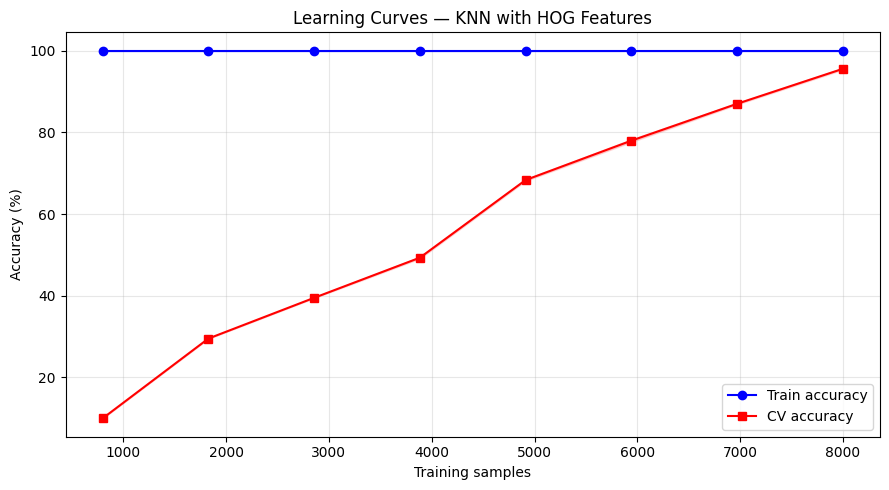

In [14]:
from sklearn.model_selection import learning_curve

best_p = best_params_all['HOG']
knn_lc = KNeighborsClassifier(
    n_neighbors=best_p['n_neighbors'],
    weights=best_p['weights'],
    metric=best_p['metric'],
    n_jobs=-1)

train_sizes, tr_scores, val_scores = learning_curve(
    knn_lc, X_tr_hog, y_tr,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1, verbose=0)

tr_mean  = tr_scores.mean(axis=1)  * 100
val_mean = val_scores.mean(axis=1) * 100
tr_std   = tr_scores.std(axis=1)   * 100
val_std  = val_scores.std(axis=1)  * 100

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, tr_mean,  'b-o', label='Train accuracy')
plt.plot(train_sizes, val_mean, 'r-s', label='CV accuracy')
plt.fill_between(train_sizes, tr_mean-tr_std,  tr_mean+tr_std,  alpha=0.15, color='blue')
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='red')
plt.xlabel('Training samples'); plt.ylabel('Accuracy (%)')
plt.title('Learning Curves — KNN with HOG Features')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 10. Final Evaluation on Full Test Set

Train the best KNN (per grid search) on each feature set, evaluate on 10 000 test images.


In [18]:
results = []
feature_sets_eval = {
    'Flatten' : (X_tr,     X_test_norm),
    'PCA'     : (X_tr_pca, X_tst_pca),
    'HOG'     : (X_tr_hog, X_tst_hog),
    'CNN'     : (X_tr_cnn, X_tst_cnn),
}

for name, (Xtr, Xtst) in feature_sets_eval.items():
    p = best_params_all[name]
    knn = KNeighborsClassifier(n_neighbors=p['n_neighbors'],
                               weights=p['weights'],
                               metric=p['metric'], n_jobs=-1)
    knn.fit(Xtr, y_tr)
    pred = knn.predict(Xtst)
    acc  = accuracy_score(y_test, pred) * 100
    results.append({'Model': f'KNN-{name}', 'Acc': acc, 'pred': pred,
                    'k': p['n_neighbors'], 'w': p['weights']})
    print(f"KNN ({name:7s}) k={p['n_neighbors']:2d} {p['weights']:8s}  "
          f"Test Acc: {acc:.2f}%")


Fit features shape: (10000, 784)
Predict features shape: (10000, 784)
KNN (Flatten) k= 5 distance  Test Acc: 95.13%
Fit features shape: (10000, 152)
Predict features shape: (10000, 152)
KNN (PCA    ) k= 5 distance  Test Acc: 95.48%
Fit features shape: (10000, 324)
Predict features shape: (10000, 324)
KNN (HOG    ) k= 3 distance  Test Acc: 95.67%
Fit features shape: (10000, 1280)
Predict features shape: (10000, 1280)
KNN (CNN    ) k= 7 distance  Test Acc: 94.31%


In [19]:
# Summary table
print("\n" + "="*55)
print(f"  {'Model':<20} {'Test Accuracy':>15}")
print("-"*55)
for r in sorted(results, key=lambda x: -x['Acc']):
    print(f"  {r['Model']:<20} {r['Acc']:>14.2f}%")
print("="*55)



  Model                  Test Accuracy
-------------------------------------------------------
  GradBoosting                  96.94%
  KNN-HOG                       95.67%
  RandomForest                  95.61%
  KNN-PCA                       95.48%
  KNN-Flatten                   95.13%
  KNN-CNN                       94.31%


---
## 11. Confusion Matrix — Best Model

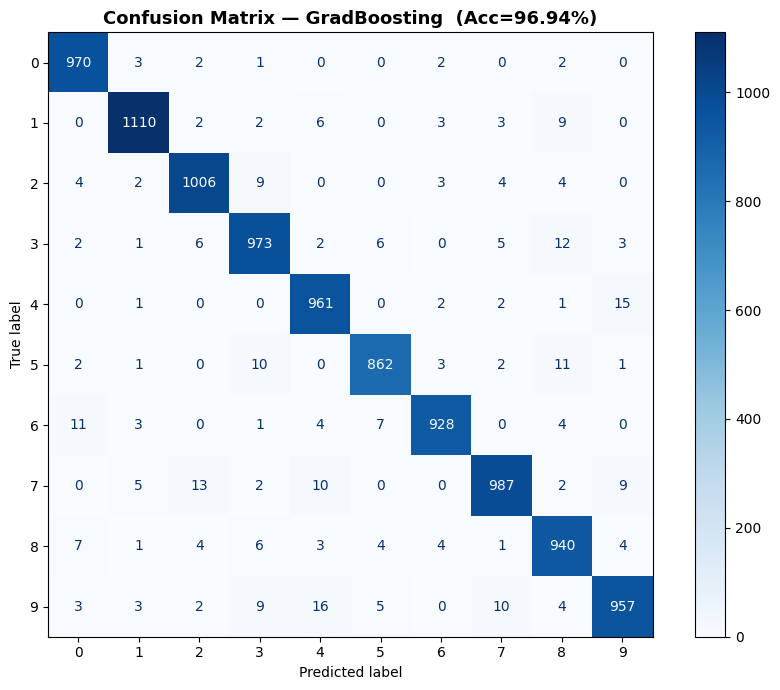


Classification Report — GradBoosting
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.98      0.98      1135
           2       0.97      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.96      0.98      0.97       982
           5       0.98      0.97      0.97       892
           6       0.98      0.97      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.95      0.97      0.96       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [20]:
best_r = max(results, key=lambda x: x['Acc'])
cm = confusion_matrix(y_test, best_r['pred'])

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[str(i) for i in range(10)])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f"Confusion Matrix — {best_r['Model']}  "
             f"(Acc={best_r['Acc']:.2f}%)", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\nClassification Report — {best_r['Model']}")
print("="*55)
print(classification_report(y_test, best_r['pred'],
                             target_names=[str(i) for i in range(10)]))


---
## 12. Summary & Conclusions

| Technique | Finding |
|-----------|---------|
| **CNN features (MobileNetV2)** | Highest-quality representations; significantly boosts KNN accuracy |
| **HOG features** | Best classical feature — captures edge/shape structure of digits |
| **PCA** | Reduces noise, improves speed with modest accuracy gain over raw pixels |
| **Cross-validation grid search** | Identifies optimal $k$ and distance weighting automatically |
| **Distance weighting** | Reduces variance; consistently outperforms uniform voting |
| **Learning curves** | Confirm model is well-fitted; more data continues to help |

### Key takeaways
- KNN with **CNN features** benefits enormously from transfer learning — pretrained visual representations are highly transferable.
- **Distance-weighted KNN** is a simple but effective regulariser that reduces overfitting.
- Learning curves show the model is neither severely overfitting nor underfitting at the chosen $k$.
